In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

# Plotting options
plot_dir = './plots'
save_filename = 'diffusion'
latex = True

# Diffusion Model

Data's ESD replicates Fig 4 (right panel) of:

* [Why Diffusion Models Don’t Memorize: The Role of Implicit Dynamical Regularization in Training](https://openreview.net/pdf?id=BSZqpqgqM0)

The data is the matrix $\mathbf{U}$ in the above paper, here generated at the size $64K \times 64K$.

The input file loaded below (`Umatrix64k_eigs.npz`) contains a list of numpy arrays. Each array is the eigenvalues of a sumbatrix, ranging from the size $1K, 2K, 4K, \dots, 64K$.

*Note:* to reproduce these results, use `_continuation_algebraic_old.py` which works better.

Idx   Size   Repeat
---  -----   ------
0     1000       16
1     1414       11
2     2000        8
3     2828        5
4     4000        4
5     5656        2
6     8000        2
7    11313        1
8    16000        1
9    22627        1
10   32000        1
11   45254        1
12   64000        1

proc name: Intel(R) Xeon(R) Gold 6126 CPU @ 2.60GHz
num proc:  48
date:      2026-04-14 03:26:08 PDT



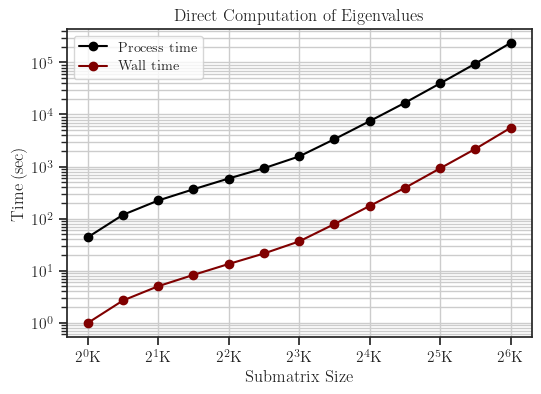

In [2]:
# Load input file
# filename = 'Umatrix64k_eigs_old.npz'
# filename = 'Umatrix64k_eigs_lsh.npz'                 # on lsh's machine
# filename = 'Umatrix64k_eigs.npz'                      # float32
filename = 'Umatrix64k_eigs_half.npz'                 # float32
# filename = 'Umatrix64kf3.2n100d0.01t_eigs.npz'          # float64
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']                   # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 2
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()
    # s = eigs_repeated[i].shape[0]
    # shift = min(s-1, 2)
    # eigs[i] = eigs_repeated[i][shift:shift+rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

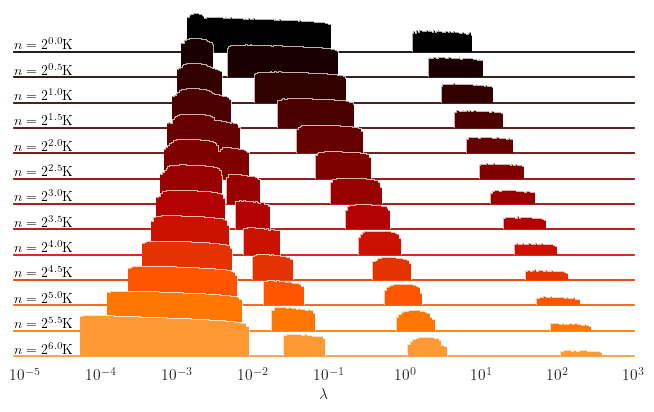

In [3]:
ridgeplot(sizes, eigs=eigs, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, title='',
          save=False, nbins=200)

# Fit Spectral Curve

In [4]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 4

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True,
                      print_info=True)

# Stieltjes options (Homotopy)
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'empirical',
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 10,
    anchor_ratio = 1,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.05,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes (Plemelj)
inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'small_delta',  # 'uniform, small_delta
)

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   support=support,
                   n=sizes[start_idx],
                   log=True,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')

# Combinations that work
# deg_m, deg_z = 8, 5
# deg_m, deg_z = 10, 5
# deg_m, deg_z = 9, 5
# deg_m, deg_z = 8, 4
# deg_m, deg_z = 7, 3
# deg_m, deg_z = 6, 6
# deg_m, deg_z = 6, 3
# deg_m, deg_z = 5, 5
deg_m, deg_z = 7, 5  # VERY GOOG

deg_mu = 4
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

coeffs = af.fit(
    deg_m, deg_z,
    reg=0,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096 // 2,
    cut_eps=0.01,
    normalize=True,
    triangular=(None, None),
    mu=mu,
    mu_reg=None, verbose=True, plot=False)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, '
#           f'weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: (  0.00072,   0.00646) | center:   0.00215 |  mass: 80.00% |
| bulk 2 | interval: (  0.03802,   0.27663) | center:   0.10255 |  mass: 17.50% |
| bulk 3 | interval: (  6.25733,  27.72341) | center:  13.17097 |  mass:  2.50% |
mass(x) ~ 0.07001 * x^(-0.3977)

------------------------------------------
fit residual max  : 1.8334e-04
fit residual 99.9%: 1.8300e-04

Coefficients (real)
+0.92129872 +0.10706827 +0.00214969 -0.00001485 +0.00000003 -0.00000000 -0.00000000 +0.00000000 
+0.03333053 +2.76065962 +0.30843113 +0.00556963 -0.00002466 +0.00000002 +0.00000000 +0.00000000 
-0.03210983 -0.06130769 +2.06668741 +0.21817490 +0.00373173 -0.00000775 -0.00000000 -0.00000000 
+0.01309757 -0.05848366 -0.09973993 +0.20675128 -0.00190726 +0.00000530 -0.00000001 +0.00000000 
+0.00016335 +0.02869190 -0.02644070 -0.00306870 +0.00003749 -0.00000012 +0.00000000 -0.00000000 
+0.00000000 +0.00016335 +0.0156

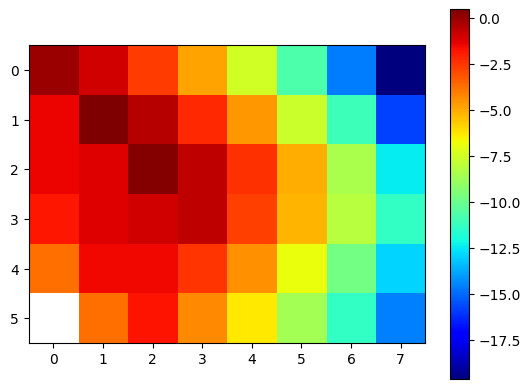

In [5]:
%matplotlib inline

p = plt.imshow(numpy.log10(numpy.abs(af.coeffs.real)), cmap=plt.cm.jet)
plt.colorbar(p)
plt.show()

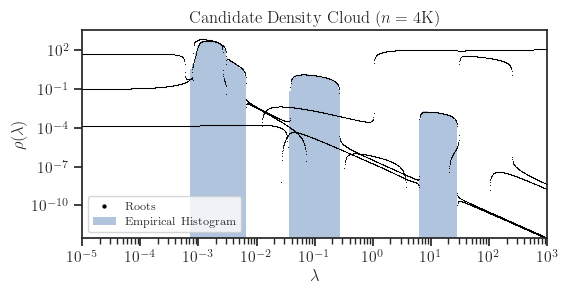

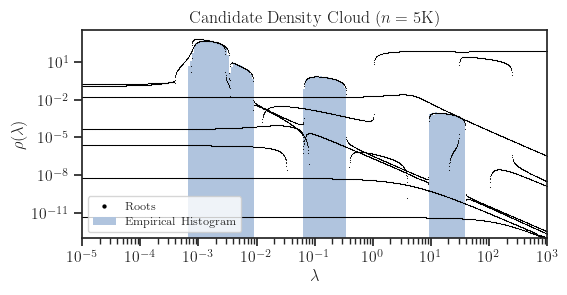

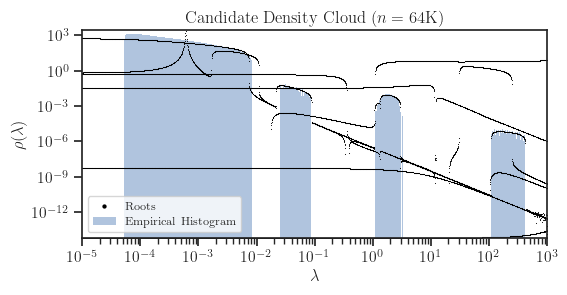

In [6]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = 1e-5
x_max = 1e3
x_highres = numpy.geomspace(x_min, x_max, 2000)

# for idx in range(start_idx, sizes.size):
for idx in [start_idx, start_idx+1, sizes.size-1]:
    af.candidates(
        size=sizes[idx],
        kind='free',
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6, latex=latex)

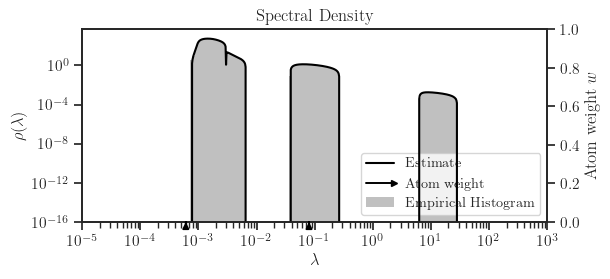


Mass: 0.99901646


In [7]:
# Plot density
x_min = 1e-5
x_max = 1e3
x0 = numpy.geomspace(x_min, x_max, 1000)
rho0 = af.density(x0, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x0)
print(f'Mass: {mass:0.8f}')

Support (estimated from polynomial):
	Interval 1: (   0.0009,    0.0063)
	Interval 2: (   0.0383,    0.2653)
	Interval 3: (   6.2467,   28.4951)


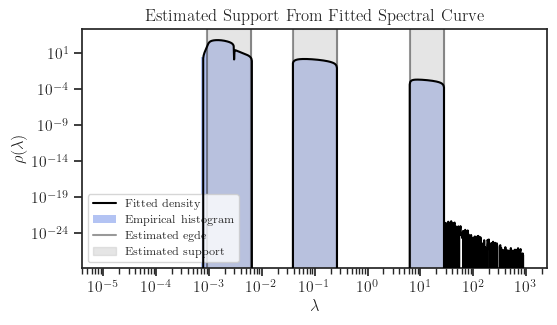

In [42]:
print('Support (estimated from polynomial):')

est_supp = af.support(refine=False, resplit_density=4, merge_threshold=0.1)

for i, supp in enumerate(est_supp):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

with texplot.theme(use_latex=latex):
    alpha = 0.4
    fig, ax = plt.subplots(figsize=(6, 3.1))
    ax.plot(x0, rho0, color='black', zorder=10, label='Fitted density')
    
    bins = numpy.geomspace(
        numpy.min(eigs[start_idx]), numpy.max(eigs[start_idx]), 150)
    ax.hist(eigs[start_idx], bins, density=True,color='royalblue',
            alpha=0.4, zorder=1, edgecolor='none',
            label='Empirical histogram')
    
    for i in range(len(est_supp)):
        label = 'Estimated egde' if i == 0 else ''
        ax.axvline(est_supp[i][0], linestyle='-', color='black', alpha=alpha, label=label)
        ax.axvline(est_supp[i][1], linestyle='-', color='black', alpha=alpha)
    
        label = 'Estimated support' if i == 0 else ''
        ax.axvspan(est_supp[i][0], est_supp[i][1], color='silver', alpha=alpha, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim([x[0], x[-1]])
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\rho(\lambda)$')
    ax.legend(fontsize='x-small', loc='lower left')
    ax.set_title('Estimated Support From Fitted Spectral Curve')
    plt.show()

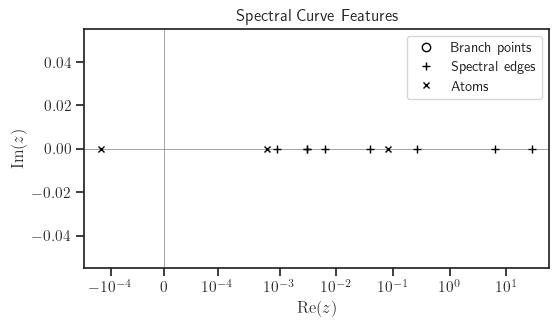


i   Branch Points        Spectral Edge
--  -------------------  -------------


In [10]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

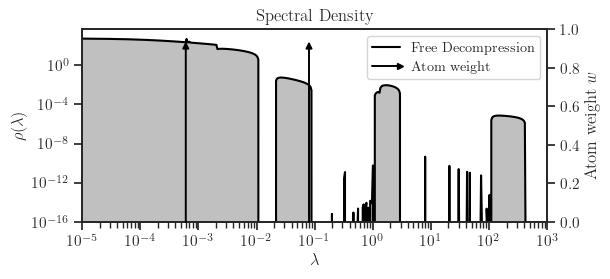

In [8]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, atoms = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [9]:
rho_clean = numpy.copy(rho)
rho_dash = numpy.copy(rho)

rho_clean = numpy.abs(rho_clean)
rho_dash = numpy.abs(rho_dash)

for i in range(rho_clean.shape[0]):

    # Dnsity below Poisson kenrel delta floor is technically zero
    poisson = (af.delta / numpy.pi) / (x**2 + af.delta**2)
    small = rho_clean[i] < poisson
    rho_clean[i, small] = 0.0
    rho_dash[i, small] = 0.0

    # Trim left edge that follows Tracy-Widom or extreme universaility
    # We will plot left edge later below
    left = x < numpy.quantile(eigs[start_idx+i], 1e-4)
    # left = x < numpy.nanmin(eigs[start_idx+i])
    left2 = x < numpy.quantile(eigs[start_idx+i], 1e-1)

    if i == 0:
        rho_clean[i, left] = 0
    else:
        rho_clean[i, left] = numpy.nan

    # if i > 0:
    rho_dash[i, left] = 1e-16
    rho_dash[i, numpy.logical_not(left2)] = numpy.nan

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-flow.pdf".


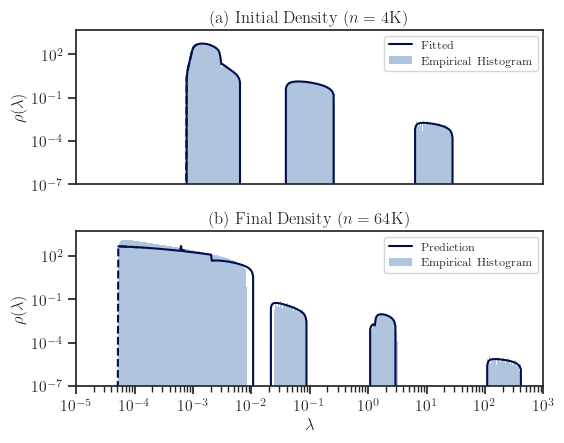

In [10]:
%matplotlib inline
plot_flow(fd_sizes, x, rho_clean, eigs[start_idx], eigs[end_idx], delta=af.delta,
          rho_dash=rho_dash,
          figsize=(5.8, 4.6),
          xlim=(1e-5, 1e3),
          ylim=(1e-7, 5e3),
          nbins=(350, 450),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          plot_middle=False,
          plot_floor=False,
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.3001),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=latex,
          save=join(plot_dir, save_filename + '-flow.pdf'))

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-ridge.pdf".


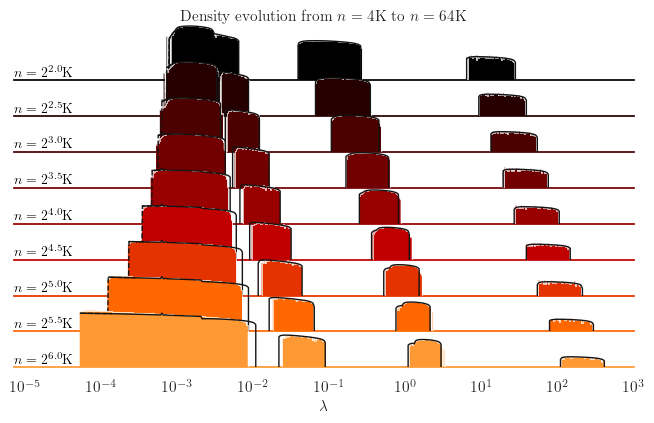

In [11]:
mask = x > numpy.min(eigs[end_idx])
gray = 0.08

%matplotlib inline
ridgeplot(sizes[start_idx:end_idx+1], x=x[mask], rho=rho_clean[:, mask],
          eigs=eigs[start_idx:end_idx+1], rho_dash=rho_dash[:, mask],
          log=True, ylim=(1e-7, 5e3), scaley=False, hspace=-0.4,
          cmap=plt.cm.gist_heat, c_range=(0, 0.8),
          rho_color=(gray, gray, gray),
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, nbins=395,
          title=r'Density evolution from $n=4$K to $n=64$K',
          save=join(plot_dir, save_filename + '-ridge.pdf'))

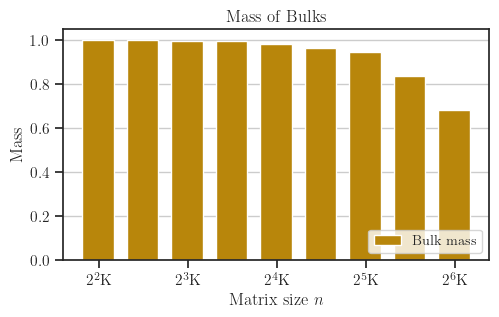

In [10]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, latex=latex,
          save=False)

# DEBUG

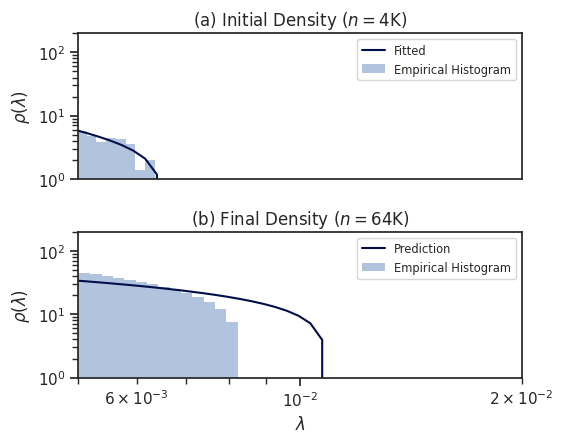

In [7]:
%matplotlib inline
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], delta=af.delta,
          figsize=(5.8, 4.6),
          xlim=(5e-3, 2e-2),
          ylim=(1e0, 2e2),
          nbins=(350, 450),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          plot_middle=False,
          plot_floor=False,
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.3001),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=False,
          save=False)

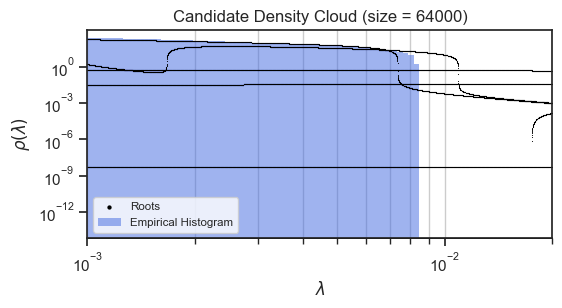

In [106]:
x_min = 1e-3
x_max = 2e-2
x_highres = numpy.geomspace(x_min, x_max, 5000)
idx = end_idx
af.candidates(
        size=sizes[idx],
        kind='free',
        x=x_highres,
        eig=eigs[idx],
        delta=1e-6, markersize=0.6, latex=False)

# Track Candidate Roots

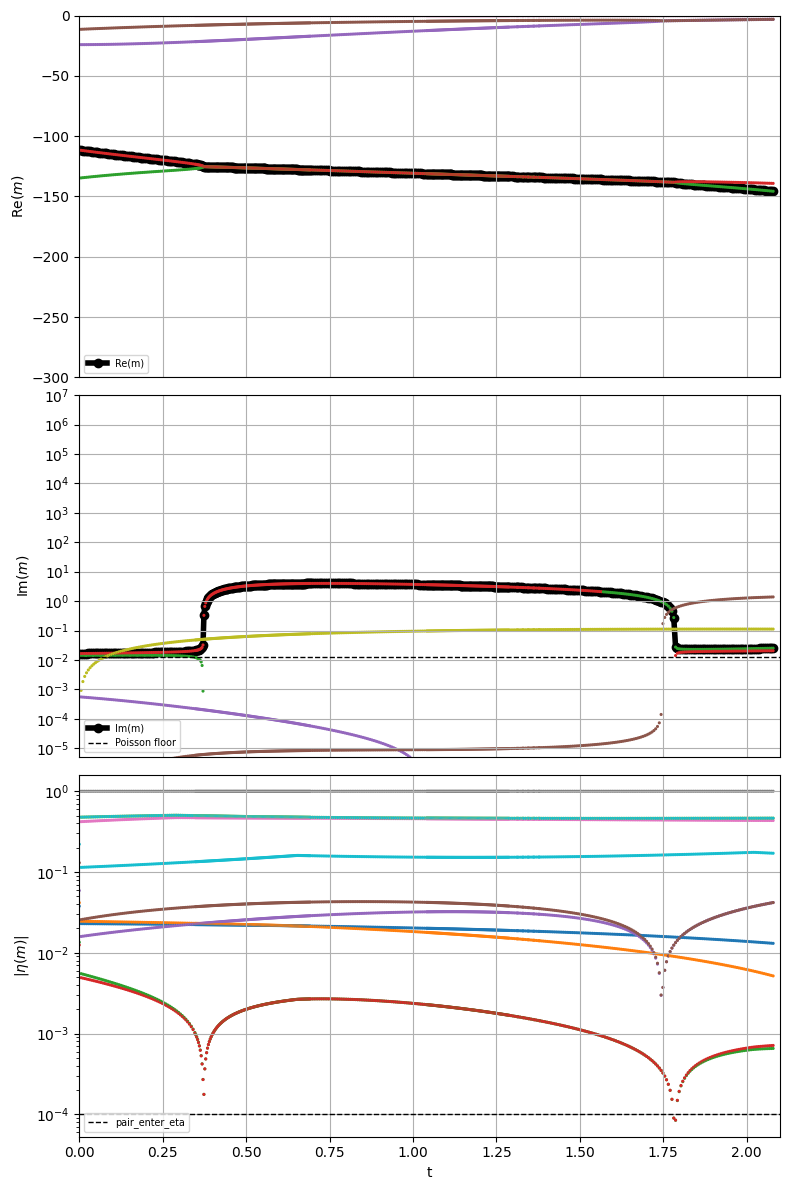

In [107]:
# %matplotlib qt
%matplotlib inline

_ = af.debug_decompress(
    fd_sizes[0:6+1],
    x=9e-3,
    # x=1e-4,
    min_n_times=500,
    newton_opt=newton_opt,
    # t_lim=[-0.05, 1.75],
    t_lim=[0.0, 2.1],
    re_lim=[-300, 0],
    # # im_lim=[1e0, 9e2],
    im_lim=[5e-6, 1e7],
)

# Edge

In [8]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(fd_sizes[-1] / fd_sizes[0])
t = numpy.linspace(0, t_final, 500)

# cusps, info = af.cusp(t, kind='free', max_iter=1000, tol=1e-7, dedup_t_tol=1e-7,
#                       dedup_x_tol=1e-7, return_info=True)

# support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
est_supp = af.support(refine=False, resplit_density=4, merge_threshold=0.01)

real_merged_edges, cusps = af.edge(
    t, kind='free', supp=est_supp, dt_max=0.01, max_iter=100, tol=1e-8)

print('Cusps:')
if len(cusps) > 0:
    for cusp in cusps:
        print(f'\tx: {cusp[0]:>0.3f}, t: {cusp[1]:>0.3f}')

Cusps:
	x: 1.111, t: 2.613


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-edge.pdf".


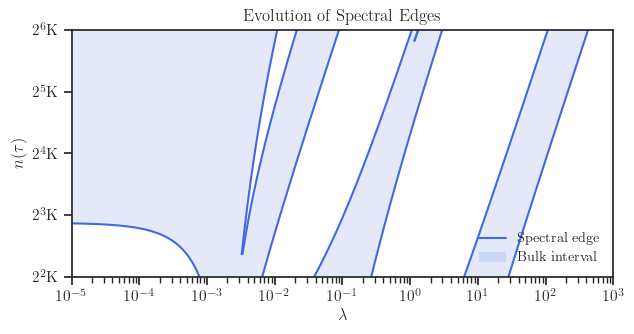

In [9]:
# Trim very close initial edges
# real_merged_edges_ = numpy.delete(real_merged_edges, [7, 8], axis=1)

plot_edges(t, real_merged_edges, cusps=None, sizes=fd_sizes,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           # edge_color='black', fill_color='gray', alpha=0.2,
           figsize=None, annotate=False, xlim=(1e-5, 1e3), log_x=True,
           log_y=True, flip_y=False,
           save=join(plot_dir, save_filename + '-edge.pdf'), latex=latex)

# Left Edge

In [13]:
# ==============
# fit shifted tw
# ==============

def fit_shifted_tw(sizes, min_eigs, sizes_eval, ngrid=2000):
    """
    Shifted Tracy-Widom lambda(n) = lambda(infty) + c n^{-2/3}.
    """
    
    sizes = numpy.asarray(sizes, float)
    min_eigs = numpy.asarray(min_eigs, float)
    sizes_eval = numpy.asarray(sizes_eval, float)

    z = sizes**(-2/3)
    agrid = numpy.linspace(0.0, float(numpy.min(min_eigs) * 0.999), ngrid)

    best_a_inf, best_C, best_mse = None, None, numpy.inf
    for a_inf in agrid:
        C = numpy.dot(z, min_eigs - a_inf) / numpy.dot(z, z)
        fit = a_inf + C * z
        mse = numpy.mean((min_eigs - fit)**2)
        if mse < best_mse:
            best_a_inf, best_C, best_mse = a_inf, C, mse

    left_edges_eval = best_a_inf + best_C * sizes_eval**(-2/3)
    
    return left_edges_eval, {"a_inf": best_a_inf, "C": best_C}

# ===========
# fit semilog
# ===========

def fit_semilog(sizes, min_eigs, sizes_eval):
    """
    Semilog lambda(n) = a + b*n.
    """
    
    sizes = numpy.asarray(sizes, float)
    min_eigs = numpy.asarray(min_eigs, float)
    sizes_eval = numpy.asarray(sizes_eval, float)

    m, b = numpy.polyfit(sizes, numpy.log(min_eigs), 1)
    left_edges_eval = numpy.exp(m * sizes_eval + b)
    
    return left_edges_eval, {"m": m, "b": b}

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-left-edge.pdf".


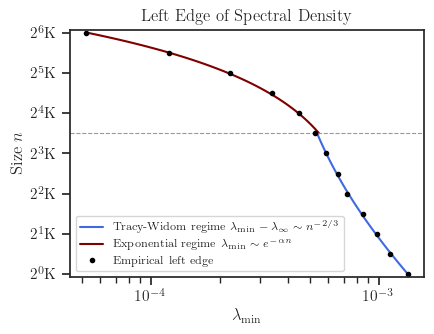

In [20]:
regime_idx = 7


min_eigs = numpy.zeros((len(eigs),))
for i in range(len(eigs)):
    min_eigs[i] = numpy.quantile(eigs[i], 0.00001)
    # support = freealg.supp(eigs[i], method='hist', tol=0, nbins=150, log=True)
    # min_eigs[i] = support[0][0]

# Tracy-Widom regime
tw_sizes = numpy.geomspace(sizes[0], sizes[regime_idx], 100)
tw_edge, tw_param = fit_shifted_tw(sizes[:regime_idx+1], min_eigs[:regime_idx+1], tw_sizes)

# Exponential regime
ll_sizes = numpy.geomspace(sizes[regime_idx], sizes[-1], 100)
ll_edge, ll_param = fit_semilog(sizes[regime_idx:], min_eigs[regime_idx:], ll_sizes)

with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(4.5, 3.5), ncols=1, sharey=False)

    ax.plot(tw_edge, tw_sizes, '-', color='royalblue',
            label=r'Tracy-Widom regime $\lambda_{\mathrm{min}} - \lambda_{\infty} \sim n^{-2/3}$')
    ax.plot(ll_edge, ll_sizes, '-', color='maroon',
            label=r'Exponential regime $\lambda_{\mathrm{min}} \sim e^{-\alpha n}$')
    ax.axhline(sizes[regime_idx], linestyle='--', color='0.6', linewidth=0.8)
    ax.plot(min_eigs, sizes, 'o', markersize=3, color='black',
            label='Empirical left edge')

    ax.set_ylim([sizes[0]/1.05, sizes[-1]*1.05])
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel(r'$\lambda_{\mathrm{min}}$')
    ax.set_ylabel(r'Size $n$')
    ax.set_title('Left Edge of Spectral Density')

    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    
    ax.legend(fontsize='x-small', loc='lower left')

    plt.tight_layout()
    # plt.show()

    # Zero pad on left, right, and top of canvas
    import matplotlib.transforms as mtransforms
    fig.canvas.draw()
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    pad = 0.75 / 72.0
    bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                         bbox.x1+pad, bbox.y1+pad)

    full_save_filename = join(plot_dir, save_filename + '-left-edge.pdf')
    save_status = True
    texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                              transparent_background=True, dpi=200,
                              bbox_inches=bbox,
                              show_and_save=save_status, verbose=True)

# Density and Left Edge

In [17]:
fd_sizes_plot = numpy.geomspace(sizes[start_idx], sizes[end_idx], t.size)

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho_plot, atoms = af.decompress(
    fd_sizes_plot, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

NameError: name 't' is not defined

In [16]:
tw_idx = fd_sizes_plot <= sizes[regime_idx]
ll_idx = fd_sizes_plot > sizes[regime_idx]

tw_n = fd_sizes_plot[tw_idx]
ll_n = fd_sizes_plot[ll_idx]

left_edges = numpy.zeros_like(fd_sizes_plot)

# Shifted Tracy-Widom regime
left_edges[tw_idx] = tw_param['a_inf'] + tw_param['C'] * fd_sizes_plot[tw_idx]**(-2/3)

# Log-linear (exponential) regime
left_edges[ll_idx] = numpy.exp(ll_param['m'] * fd_sizes_plot[ll_idx] + ll_param['b'])

In [24]:
# Trim very close initial edges or spurious edges
real_merged_edges_ = numpy.delete(real_merged_edges, [5, 6], axis=1)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-edge2.pdf".


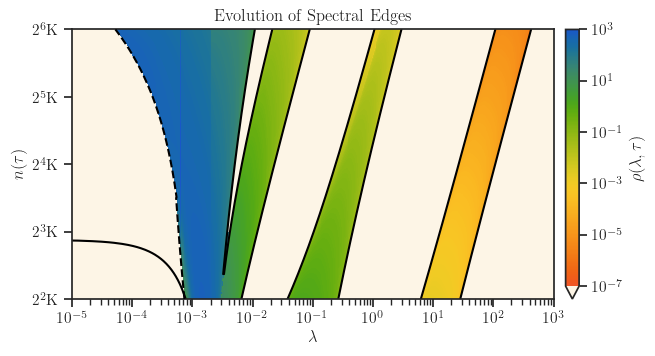

In [21]:
import colorcet as cc
from matplotlib.colors import LogNorm

t_ = sizes[start_idx] * numpy.exp(t)
xx, tt_ = numpy.meshgrid(x, t_)

poisson = (af.delta / numpy.pi) / (xx**2 + af.delta**2)
r = numpy.copy(rho_plot)
# r = numpy.abs(r)
# r[r < poisson] = numpy.nan
# r[r < poisson] = poisson[r < poisson]

# r[(r < 1e-7) & numpy.logical_not(near_cusp)] = numpy.nan
# r[(numpy.abs(r) < 1e-7)] = numpy.nan
r[r < 1e-7] = numpy.nan

# Repair nan points very close to cusp
near_cusp = (tt_ < 8e3) & (xx > 2e-3) & (xx < 5e-3)
repair = near_cusp & numpy.isnan(r)
r[repair] = 1e2 # poisson[repair]
r[(xx < left_edges[:, None])] = numpy.nan


# t_emp = numpy.log(sizes[start_idx:end_idx+1] / sizes[start_idx])
# t_emp = sizes[start_idx:end_idx+1]
# e_emp = min_eigs[start_idx:end_idx+1]

# cmap = plt.cm.YlOrRd
cmap = cc.cm.CET_R1_r
# cmap = cc.cm.CET_R4_r
cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.2, 0.95, 256)))
bg_color = 'oldlace'
cmap_trim.set_under(bg_color)
# cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(0.1, 0.7, 256)))

with texplot.theme(use_latex=True):
    fig, ax = plt.subplots(figsize=(7.5, 3.5))

    p = ax.pcolormesh(xx, tt_, r,
                      # norm=LogNorm(vmin=numpy.nanmin(r), vmax=numpy.nanmax(r)),
                      norm=LogNorm(vmin=1e-7, vmax=1e3),
                      cmap=cmap_trim, rasterized=True)
    
    ax.plot(real_merged_edges_, t_, color='0.0')
    # ax.plot(e_emp, t_emp, '--', color='black', zorder=10)
    ax.plot(left_edges, t_, '--', color='black', zorder=10)
    
    ax.set_facecolor(bg_color)
    
    ax.set_ylim([t_[0], t_[-1]])
    ax.set_xscale('log')

    # cbar = plt.colorbar(p, pad=0.02)
    cbar = plt.colorbar(p, pad=0.02, extend='min')
    cbar.set_label(r'$\rho(\lambda, \tau)$')
    cbar.solids.set_rasterized(True)
    cbar.ax.minorticks_off()

    cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
    cbar.ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs='auto'))
    cbar.ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax.set_yscale('log', base=2)
    ax.yaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))

    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$n(\tau)$')
    ax.set_title('Evolution of Spectral Edges')
    # plt.show()

    fig.patch.set_alpha(0)

    # Zero pad on left, right, and top of canvas
    import matplotlib.transforms as mtransforms
    fig.canvas.draw()
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    pad = 0.5 / 72.0
    bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                         bbox.x1+pad, bbox.y1+pad)

    full_save_filename = join(plot_dir, save_filename + '-edge2.pdf')
    save_status = True
    save_status = True
    texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                  transparent_background=False, dpi=200,
                                  bbox_inches=bbox,
                                  show_and_save=save_status, verbose=True)

# Tables

In [4]:
# ================
# set delta_ladder
# ================

def set_delta_ladder(delta_ladder_size, method, fit_degree=2):
    """
    To benchmakr with only ont evaluation of density at one
    delta distance, set af.delta_ladder, like

    >>> set_delta_ladder(delta_ladder_size=1, method='direct', fit_degree=2)

    To return back to previosu behavior, set

    >>> set_delta_ladder(delta_ladder_size=4, method='chebfit', fit_degree=2)
    """
    
    af.inv_stieltjes_opt['delta_ladder_size'] = delta_ladder_size
    af.inv_stieltjes_opt['method'] = method
    af.inv_stieltjes_opt['fit_degree'] = fit_degree
        
    delta_ladder_grid = inv_stieltjes_opt['delta_ladder_grid']
    delta_ladder_ratio = inv_stieltjes_opt['delta_ladder_ratio']
    delta_ladder_size = inv_stieltjes_opt['delta_ladder_size']
    
    # Type of grid to produces multiple deltas for Plemelj
    if delta_ladder_grid == 'geometric':
        af.delta_ladder = af.delta * (
                delta_ladder_ratio **
                numpy.arange(delta_ladder_size, dtype=int))
    elif delta_ladder_grid == 'linear':
        af.delta_ladder = af.delta * \
            numpy.arange(1, delta_ladder_size+1, dtype=int)

    print('\nChanged af.delta_ladder to:')
    print(af.delta_ladder)
    print('')

# Runtime

To correctly measure runtime, do these:

1. `ssh mm340`
2. Export these
   ```
       export OMP_NUM_THREADS=1
       export OPENBLAS_NUM_THREADS=1
       export MKL_NUM_THREADS=1
       export NUMEXPR_NUM_THREADS=1
   ```
3. In `newton_opt`, set
   ```
       parallel=False
       n_jobs=1
   ```

In [67]:
import time, resource

def cpu_total_with_children():
    self = resource.getrusage(resource.RUSAGE_SELF)
    kids = resource.getrusage(resource.RUSAGE_CHILDREN)
    return self.ru_utime + self.ru_stime + kids.ru_utime + kids.ru_stime

# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']

set_delta_ladder(delta_ladder_size=1, method='direct')

# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 200)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=False,
    n_jobs=1,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

repeats = 5
fd_wall_times = numpy.zeros((fd_sizes.size,), dtype=float)
fd_proc_times = numpy.zeros((fd_sizes.size,), dtype=float)

i=0
print(f'Size: {fd_sizes[i]:>5d} ' + '.'*repeats, end='')
print(f' | fd wall time: {fd_wall_times[i]:>6.1f}'
      f' | fd proc time: {fd_proc_times[i]:>6.1f}'
      f' | direct proc time: {proc_times[i]:>9.1f}')

for i in numpy.arange(1, fd_sizes.size):

    print(f'Size: {fd_sizes[i]:>5d} ', end='')

    for j in range(repeats):

        print(f'.', end='')

        init_wall_time = time.time()
        init_proc_time = cpu_total_with_children()
        # init_proc_time = time.process_time()

        min_n_times = int(100 * fd_sizes[i] / fd_sizes[-1])
        
        rho_bnch, _ = af.decompress(
            fd_sizes[0:i+1], x=x, kind='free', method='moc', min_n_times=min_n_times,
            newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
            verbose=False, plot=False, latex=latex)

        fd_wall_times[i] += time.time() - init_wall_time
        fd_proc_times[i] += cpu_total_with_children() - init_proc_time
        # fd_proc_times[i] += time.process_time() - init_proc_time

    fd_wall_times[i] /= repeats
    fd_proc_times[i] /= repeats

    print(f' | fd wall time: {fd_wall_times[i]:>6.1f}'
          f' | fd proc time: {fd_proc_times[i]:>6.1f}'
          f' | direct proc time: {proc_times[start_idx+i]:>9.1f}')

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)

[1.e-06]
Size:  4000 .. | fd wall time:    0.0 | fd proc time:    0.0 | direct proc time:   43.7
Size:  5656 .. | fd wall time:   13.2 | fd proc time:  100.1 | direct proc time:  927.4
Size:  8000 .. | fd wall time:   13.5 | fd proc time:  102.6 | direct proc time: 1563.1
Size: 11313 .. | fd wall time:   13.2 | fd proc time:   99.3 | direct proc time: 3352.3
Size: 16000 .. | fd wall time:   13.4 | fd proc time:  102.2 | direct proc time: 7434.6
Size: 22627 .. | fd wall time:   16.2 | fd proc time:  122.2 | direct proc time: 16743.4
Size: 32000 .. | fd wall time:   16.2 | fd proc time:  122.2 | direct proc time: 39561.7
Size: 45254 .. | fd wall time:   14.4 | fd proc time:  109.5 | direct proc time: 94775.3
Size: 64000 .. | fd wall time:   16.7 | fd proc time:  126.1 | direct proc time: 237098.2
[1.e-06]


# Distributional Comparison (Table)

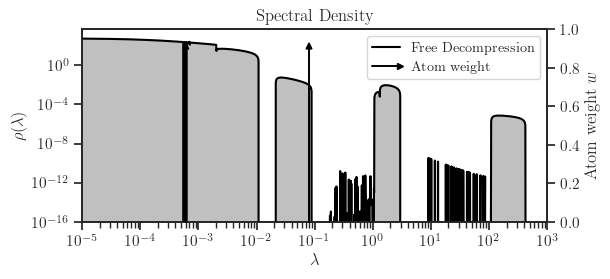

In [5]:
# Choosing the largest sub-matrix size to decompress to
end_idx = sizes.size - 1

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 2000)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, atoms = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

In [6]:
rho_cut = rho.copy()
for i in range(rho_cut.shape[0]):
    rho_cut[i, x < numpy.min(eigs[start_idx + i])] = 0.0

In [8]:
import numpy
from scipy.stats import ks_2samp, wasserstein_distance
from freealg import sample


def sample_tv_log(eig_emp, eig_fd, bins=150, xrange=None):
    """Histogram-based TV using log-spaced bins."""
    if xrange is None:
        lo = max(min(eig_emp.min(), eig_fd.min()), numpy.finfo(float).tiny)
        hi = max(eig_emp.max(), eig_fd.max())
    else:
        lo, hi = xrange

    eig_emp = eig_emp[(eig_emp >= lo) & (eig_emp <= hi)]
    eig_fd = eig_fd[(eig_fd >= lo) & (eig_fd <= hi)]

    edges = numpy.geomspace(lo, hi, bins + 1)

    hist_emp, edges = numpy.histogram(eig_emp, bins=edges, density=True)
    hist_fd, _ = numpy.histogram(eig_fd, bins=edges, density=True)

    dx = numpy.diff(edges)
    return 0.5 * numpy.sum(numpy.abs(hist_emp - hist_fd) * dx)


def density_moment(rho_i, x, k):
    """Compute unnormalized int x^k rho(x) dx."""
    return numpy.trapz((x**k) * rho_i, x)


def gaussian_mmd2_biased(a, b, sigma=None, max_pts=4000, seed=0):
    """Biased Gaussian MMD^2. Returns value in [0, 2]."""
    rng = numpy.random.default_rng(seed)

    a = numpy.asarray(a)
    b = numpy.asarray(b)

    if a.size > max_pts:
        a = rng.choice(a, size=max_pts, replace=False)
    if b.size > max_pts:
        b = rng.choice(b, size=max_pts, replace=False)

    a = a[:, None]
    b = b[:, None]

    if sigma is None:
        z = numpy.vstack([a, b]).ravel()
        dz = numpy.abs(z[:, None] - z[None, :])
        sigma = numpy.median(dz[dz > 0])
        if not numpy.isfinite(sigma) or sigma <= 0:
            sigma = 1.0

    k_aa = numpy.exp(-0.5 * ((a - a.T) / sigma)**2).mean()
    k_bb = numpy.exp(-0.5 * ((b - b.T) / sigma)**2).mean()
    k_ab = numpy.exp(-0.5 * ((a - b.T) / sigma)**2).mean()

    return k_aa + k_bb - 2.0 * k_ab


tv = []
ks = []
w1 = []
w1_norm = []
mmd = []
mu1_err = []
mu2_err = []
std_err = []

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])
    rho_fd = rho_cut[j]

    eig_fd = sample(
        x, rho_fd,
        num_pts=eig_emp.size,
        method='qmc',
        seed=start_idx + j,
    )

    tv_i = sample_tv_log(
        eig_emp, eig_fd,
        bins=450,
        xrange=(numpy.min(eig_emp), numpy.max(eig_emp)),
    )

    ks_i = ks_2samp(eig_emp, eig_fd).statistic

    log_emp = numpy.log(eig_emp[eig_emp > 0])
    log_fd = numpy.log(eig_fd[eig_fd > 0])

    w1_i = wasserstein_distance(eig_emp, eig_fd)
    log_L_i = numpy.ptp(log_emp)
    w1_norm_i = wasserstein_distance(log_emp, log_fd) / log_L_i

    # MMD on log eigenvalues; report MMD^2 / 2 as a [0, 1]-scaled number.
    mmd_i = 0.5 * gaussian_mmd2_biased(
        log_emp, log_fd, sigma=None, max_pts=4000, seed=start_idx + j)

    mu1_emp = numpy.mean(eig_emp)
    mu2_emp = numpy.mean(eig_emp**2)
    std_emp = numpy.std(eig_emp)

    mu1_fd = density_moment(rho_fd, x, 1)
    mu2_fd = density_moment(rho_fd, x, 2)
    std_fd = numpy.sqrt(mu2_fd - mu1_fd**2)

    mu1_err_i = numpy.abs(mu1_fd - mu1_emp) / numpy.abs(mu1_emp)
    mu2_err_i = numpy.abs(mu2_fd - mu2_emp) / numpy.abs(mu2_emp)
    std_err_i = numpy.abs(std_fd - std_emp) / numpy.abs(std_emp)

    tv.append(tv_i)
    ks.append(ks_i)
    w1.append(w1_i)
    w1_norm.append(w1_norm_i)
    mmd.append(mmd_i)
    mu1_err.append(mu1_err_i)
    mu2_err.append(mu2_err_i)
    std_err.append(std_err_i)

tv = numpy.asarray(tv)
ks = numpy.asarray(ks)
w1 = numpy.asarray(w1)
w1_norm = numpy.asarray(w1_norm)
mmd = numpy.asarray(mmd)
mu1_err = numpy.asarray(mu1_err)
mu2_err = numpy.asarray(mu2_err)
std_err = numpy.asarray(std_err)

print(
    f"{'n':>6}  {'TV':>6}  {'KS':>6}  {'W1/L':>7}  {'MMD':>7}  "
    f"{'mu1 err':>8}  {'mu2 err':>8}  {'std err':>8}"
)
print("-" * 70)

for j, n in enumerate(fd_sizes):
    print(
        f"{int(n):6d}  "
        f"{100*tv[j]:5.1f}%  "
        f"{100*ks[j]:5.1f}%  "
        f"{100*w1_norm[j]:6.2f}%  "
        f"{100*mmd[j]:6.2f}%  "
        f"{100*mu1_err[j]:7.2f}%  "
        f"{100*mu2_err[j]:7.2f}%  "
        f"{100*std_err[j]:7.2f}%"
    )

     n      TV      KS     W1/L      MMD   mu1 err   mu2 err   std err
----------------------------------------------------------------------
  4000    2.0%    0.2%    0.01%    0.01%     0.02%     0.03%     0.01%
  5656    3.5%    1.6%    0.13%    0.02%     0.05%     0.14%     0.07%
  8000    5.3%    2.7%    0.27%    0.08%     0.01%     0.06%     0.03%
 11313    6.6%    3.4%    0.40%    0.10%     0.01%     0.00%     0.00%
 16000    7.4%    4.2%    0.51%    0.12%     0.00%     0.00%     0.00%
 22627    7.9%    5.0%    0.64%    0.13%     0.04%     0.11%     0.06%
 32000    8.6%    5.9%    0.81%    0.15%     0.06%     0.17%     0.08%
 45254   10.0%    7.1%    1.16%    0.18%     0.02%     0.06%     0.03%
 64000   14.6%    9.6%    2.33%    0.54%     0.09%     0.20%     0.10%


### Mass of Bulks

In [8]:
import numpy

bulk_mass_err = numpy.full((len(fd_sizes), 4), numpy.nan)

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])
    rho_fd = rho_cut[j]  # or rho[j]

    supp_j = freealg.supp(
        eig_emp,
        method='hist',
        tol=0,
        nbins=150,
        log=True,
        print_info=False,
    )

    for b, (a, c) in enumerate(supp_j[:4]):
        mask_x = (x >= a) & (x <= c)
        mask_e = (eig_emp >= a) & (eig_emp <= c)

        mass_fd = numpy.trapz(rho_fd[mask_x], x[mask_x])
        mass_emp = numpy.mean(mask_e)

        bulk_mass_err[j, b] = (
            numpy.abs(mass_fd - mass_emp) / numpy.abs(mass_emp)
        )

print(
    f"{'n':>6}  {'bulk 0':>8}  {'bulk 1':>8}  "
    f"{'bulk 2':>8}  {'bulk 3':>8}"
)
print("-" * 46)

for j, n in enumerate(fd_sizes):
    vals = []
    for b in range(4):
        if numpy.isnan(bulk_mass_err[j, b]):
            vals.append(f"{'--':>8}")
        else:
            vals.append(f"{100*bulk_mass_err[j, b]:7.1f}%")

    print(f"{int(n):6d}  " + "  ".join(vals))

     n    bulk 0    bulk 1    bulk 2    bulk 3
----------------------------------------------
  4000      0.0%      0.0%      0.6%        --
  5656      0.3%      0.0%      0.4%        --
  8000      1.9%     14.7%      0.0%      0.5%
 11313      5.5%      7.8%      0.1%      0.6%
 16000     10.0%     13.6%      0.2%      0.6%
 22627     15.0%     12.4%      0.3%      0.6%
 32000     20.6%      9.3%      0.1%      0.4%
 45254     26.7%     12.4%      0.0%      0.2%
 64000     38.6%     13.5%      0.1%      0.1%


### Compare Left Bulk with Atom Dynamics

In [10]:
w0 = 0.80
n0 = fd_sizes[0]

# First row where spike bulk is separated from the next bulk.
ref_j = 2   # fd_sizes[2] = 8000

# Reference atom location from empirical spike center at n=8000.
eig_ref = numpy.asarray(eigs[start_idx + ref_j])
supp_ref = freealg.supp(
    eig_ref, method='hist', tol=0, nbins=150, log=True,
    print_info=False,
)
a_ref, b_ref = supp_ref[0]
x_atom_ref = numpy.mean(eig_ref[(eig_ref >= a_ref) & (eig_ref <= b_ref)])

bulk0_emp = []
bulk0_atom = []
bulk0_atom_err = []
center_emp = []
center_err = []

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])

    supp_j = freealg.supp(
        eig_emp,
        method='hist',
        tol=0,
        nbins=150,
        log=True,
        print_info=False,
    )

    # Empirical spike-like bulk.
    # At early rows this may be merged, but mass still tracks the atom law.
    a, b = supp_j[0]
    mask = (eig_emp >= a) & (eig_emp <= b)

    mass_emp = numpy.mean(mask)
    center_emp_i = numpy.mean(eig_emp[mask])

    t_j = numpy.log(n / n0)
    mass_atom = 1.0 - (1.0 - w0) * numpy.exp(-t_j)

    bulk0_emp.append(mass_emp)
    bulk0_atom.append(mass_atom)
    bulk0_atom_err.append(numpy.abs(mass_atom - mass_emp))
    center_emp.append(center_emp_i)
    center_err.append(numpy.abs(center_emp_i - x_atom_ref) / numpy.abs(x_atom_ref))

bulk0_emp = numpy.asarray(bulk0_emp)
bulk0_atom = numpy.asarray(bulk0_atom)
bulk0_atom_err = numpy.asarray(bulk0_atom_err)
center_emp = numpy.asarray(center_emp)
center_err = numpy.asarray(center_err)

print(f"Reference atom center from n={int(fd_sizes[ref_j])}: {x_atom_ref:.4e}")
print(
    f"{'n':>6}  {'emp mass':>9}  {'atom law':>9}  {'mass err':>8}  "
    f"{'center':>11}  {'center err':>10}"
)
print("-" * 67)

for j, n in enumerate(fd_sizes):
    print(
        f"{int(n):6d}  "
        f"{100*bulk0_emp[j]:8.1f}%  "
        f"{100*bulk0_atom[j]:8.1f}%  "
        f"{100*bulk0_atom_err[j]:7.1f}%  "
        f"{center_emp[j]:11.3e}  "
        f"{100*center_err[j]:9.1f}%"
    )

Reference atom center from n=8000: 1.8069e-03
     n   emp mass   atom law  mass err       center  center err
-------------------------------------------------------------------
  4000      80.0%      80.0%      0.0%    1.873e-03        3.7%
  5656      85.9%      85.9%      0.0%    1.875e-03        3.8%
  8000      88.8%      90.0%      1.3%    1.807e-03        0.0%
 11313      92.0%      92.9%      0.9%    1.807e-03        0.0%
 16000      94.4%      95.0%      0.6%    1.809e-03        0.1%
 22627      96.0%      96.5%      0.4%    1.811e-03        0.2%
 32000      97.2%      97.5%      0.3%    1.813e-03        0.4%
 45254      98.0%      98.2%      0.2%    1.813e-03        0.4%
 64000      98.6%      98.8%      0.2%    1.814e-03        0.4%


### Error of Edges

In [17]:
real_merged_edges_clean = numpy.delete(real_merged_edges, [5, 6], axis=1)
t_fd = numpy.log(fd_sizes / fd_sizes[0])

all_edge_err = []
mean_edge_err = []
max_edge_err = []

print(f"{'n':>6}  {'mean err':>9}  {'max err':>8}  {'edge errors'}")
print("-" * 72)

for j, n in enumerate(fd_sizes):
    eig_emp = numpy.asarray(eigs[start_idx + j])

    supp_j = freealg.supp(
        eig_emp,
        method='hist',
        tol=0,
        nbins=150,
        log=True,
        print_info=False,
    )

    emp_edges = numpy.array([v for interval in supp_j for v in interval])
    emp_edges = numpy.sort(emp_edges)

    k = numpy.argmin(numpy.abs(t - t_fd[j]))
    fd_edges = real_merged_edges_clean[k]
    fd_edges = fd_edges[numpy.isfinite(fd_edges)]
    fd_edges = numpy.sort(fd_edges)

    # Drop leftmost edge of spike bulk from both sets.
    emp_edges = emp_edges[1:]
    fd_edges = fd_edges[1:]

    matched_fd = []
    err = []

    for emp_edge in emp_edges:
        q = numpy.argmin(numpy.abs(numpy.log(fd_edges) - numpy.log(emp_edge)))
        fd_edge = fd_edges[q]
        matched_fd.append(fd_edge)

        log_xrange = numpy.log(x[-1]) - numpy.log(x[0])
        err.append(numpy.abs(numpy.log(fd_edge) - numpy.log(emp_edge)) / log_xrange)
        # err.append(numpy.abs(fd_edge - emp_edge) / numpy.abs(emp_edge))

    err = numpy.asarray(err)

    all_edge_err.append(err)
    mean_edge_err.append(numpy.mean(err))
    max_edge_err.append(numpy.max(err))

    err_str = ", ".join([f"{100*e:.1f}%" for e in err])

    print(
        f"{int(n):6d}  "
        f"{100*mean_edge_err[-1]:8.1f}%  "
        f"{100*max_edge_err[-1]:7.1f}%  "
        f"{err_str}"
    )

mean_edge_err = numpy.asarray(mean_edge_err)
max_edge_err = numpy.asarray(max_edge_err)

     n   mean err   max err  edge errors
------------------------------------------------------------------------
  4000       0.1%      0.2%  0.0%, 0.0%, 0.2%, 0.0%, 0.1%
  5656       0.2%      0.4%  0.1%, 0.1%, 0.4%, 0.1%, 0.1%
  8000       0.2%      0.5%  0.3%, 0.1%, 0.3%, 0.2%, 0.5%, 0.2%, 0.1%
 11313       0.2%      0.5%  0.2%, 0.5%, 0.2%, 0.1%, 0.2%, 0.2%, 0.1%
 16000       0.2%      0.2%  0.1%, 0.2%, 0.2%, 0.1%, 0.2%, 0.2%, 0.1%
 22627       0.3%      0.5%  0.4%, 0.4%, 0.1%, 0.1%, 0.5%, 0.2%, 0.1%
 32000       0.4%      0.8%  0.8%, 0.7%, 0.3%, 0.1%, 0.6%, 0.1%, 0.1%
 45254       0.3%      0.8%  0.8%, 0.4%, 0.2%, 0.2%, 0.5%, 0.1%, 0.1%
 64000       0.4%      1.2%  1.2%, 0.4%, 0.2%, 0.0%, 0.8%, 0.1%, 0.0%


# Compare Inv Stieltjes


Changed af.delta_ladder to:
[1.e-06]


Changed af.delta_ladder to:
[1.e-06 2.e-06 3.e-06 4.e-06]

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-inv-stieltjes.pdf".


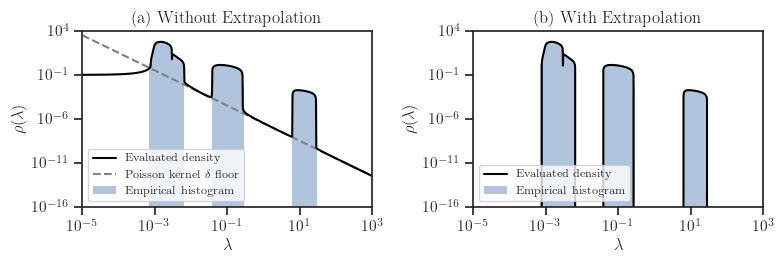


Changed af.delta_ladder to:
[1.e-06 2.e-06 3.e-06 4.e-06]



In [6]:
# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']

x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 1000)
bins = numpy.geomspace(x_min, x_max, 200)

poisson = (af.delta / numpy.pi) / (af.delta**2 + x**2)

with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(8, 2.8), ncols=2)

    for i in range(len(ax)):

        if i == 0:
            set_delta_ladder(delta_ladder_size=1, method='direct')
            title = '(a) Without Extrapolation'
        elif i == 1:
            set_delta_ladder(delta_ladder_size=4, method='chebfit')
            title = '(b) With Extrapolation'
        
        rho = af.density(x)
        ax[i].plot(x, rho, color='black', label='Evaluated density')

        if i == 0:
            ax[i].plot(x, poisson, '--', color='0.5', zorder=-1, label=r'Poisson kernel $\delta$ floor')
        ax[i].hist(eigs[start_idx], bins=bins, density=True, color='lightsteelblue', edgecolor='none',
                   zorder=-2, label='Empirical histogram', rasterized=True)
    
        ax[i].set_xlim([x_min, x_max])
        ax[i].set_ylim([1e-16, 1e4])
        ax[i].set_xscale('log')
        ax[i].set_yscale('log')
        ax[i].set_xlabel(r'$\lambda$')
        ax[i].set_ylabel(r'$\rho(\lambda)$')
        ax[i].set_title(title)
        ax[i].legend(fontsize='x-small', loc='lower left')

    plt.tight_layout()
    fig.patch.set_alpha(0)

    # Zero pad on left, right, and top of canvas
    import matplotlib.transforms as mtransforms
    fig.canvas.draw()
    bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    pad = 0.5 / 72.0
    bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                         bbox.x1+pad, bbox.y1+pad)

    full_save_filename = join(plot_dir, save_filename + '-inv-stieltjes.pdf')
    save_status = True
    save_status = True
    texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                  transparent_background=False, dpi=200,
                                  bbox_inches=bbox,
                                  show_and_save=save_status, verbose=True)

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)

# Candidtaes

In [20]:
from freealg._algebraic_form._decompress_coeffs2 import decompress_coeffs, plot_decompress_candidates

# =========================
# plot candidate comparison
# =========================

def plot_candidate_comparison(x_cand, coeffs_i, x_rho, rho, bins, eigs, xlim, ylim,
                              suffix, cut=None, rho2=None):

    with texplot.theme(use_latex=latex):
        if rho2 is None:
            fig, ax = plt.subplots(figsize=(8, 2.8), ncols=2)
        else:
            fig, ax = plt.subplots(figsize=(10, 2.8), ncols=3, sharey=True)
        
        plot_decompress_candidates(coeffs_i, x_cand, ax=ax[0], eig=eigs, delta=af.delta,
                                   size=int(alpha*af.n),
                                   log=af._log,
                                   markersize=0.6, ylim=ylim,
                                   latex=latex, verbose=True)

        poisson = (af.delta / numpy.pi) / (af.delta**2 + x**2)

        if rho2 is not None:
            rho2[rho2 < poisson] = 0.0

        if cut is not None:
            rho[x_rho < cut] = numpy.nan

            if rho2 is not None:
                rho2[x_rho < cut] = numpy.nan
    
        ax[1].plot(x_rho, rho, color='black', label='Physical density')
        ax[1].hist(eigs, bins=bins, density=True, color='lightsteelblue', edgecolor='none',
                       zorder=-2, label='Empirical histogram', rasterized=True)

        if cut is not None:
            idx = numpy.flatnonzero(~numpy.isnan(rho))[0]
            ax[0].plot([cut, cut], [ylim[0], rho[idx]], '--', color='black', zorder=1, linewidth=0.8)
            ax[1].plot([cut, cut], [ylim[0], rho[idx]], '--', color='black', zorder=1, linewidth=0.8)

            if rho2 is not None:
                ax[2].plot([cut, cut], [ylim[0], rho[idx]], '--', color='black', zorder=1, linewidth=0.8)

        if rho2 is not None:
            ax[2].plot(x_rho, rho2, color='black', label='Physical density')
            ax[2].hist(eigs, bins=bins, density=True, color='lightsteelblue', edgecolor='none',
                           zorder=-2, label='Empirical histogram', rasterized=True)

        if rho2 is not None:
            ax[1].plot(x, poisson, '--', color='0.5', zorder=-1, label=r'Poisson kernel $\delta$ floor')

        ax[0].set_title('(a) All Polynomial Roots')
        ax[0].set_ylabel(r'$\frac{1}{\pi} \Im m_i(\lambda + \delta i)$')

        ax[0].set_xlim(xlim)

        for i in range(1, len(ax)):
            ax[i].set_xlim(xlim)
            ax[i].set_ylim(ylim)
            ax[i].set_xscale('log')
            ax[i].set_yscale('log')
            ax[i].set_xlabel(r'$\lambda$')
        
            ax[i].set_ylabel(r'$\rho(\lambda) = \frac{1}{\pi} \Im m_1(\lambda + \delta i)$')

            if i == 1:
                ax[i].set_title('(b) Density from Physical Root')
            elif i == 2:
                ax[i].set_title(r'(c) Density Extrapolated to $\delta=0$')
        
            ax[i].legend(fontsize='x-small', loc='lower left')

            if rho2 is not None:
                ax[i].set_ylabel("")
                ax[i].tick_params(axis="y", left=False, labelleft=False)
    
        plt.tight_layout()
        fig.patch.set_alpha(0)
    
        # Zero pad on left, right, and top of canvas
        import matplotlib.transforms as mtransforms
        fig.canvas.draw()
        bbox = fig.get_tightbbox(fig.canvas.get_renderer())
        pad = 0.5 / 72.0
        bbox = mtransforms.Bbox.from_extents(bbox.x0-pad, bbox.y0-pad,
                                             bbox.x1+pad, bbox.y1+pad)
    
        full_save_filename = join(plot_dir, save_filename + '-candidates' + suffix + '.pdf')
        save_status = True
        save_status = True
        texplot.show_or_save_plot(plt, default_filename=full_save_filename,
                                      transparent_background=False, dpi=200,
                                      bbox_inches=bbox,
                                      show_and_save=save_status, verbose=True)


Changed af.delta_ladder to:
[1.e-06]

Max density: 110627.66619655753
Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-candidatesinit.pdf".


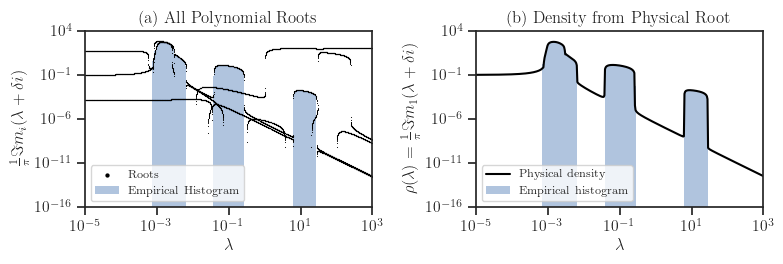


Changed af.delta_ladder to:
[1.e-06 2.e-06 3.e-06 4.e-06]



In [8]:
# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']
set_delta_ladder(delta_ladder_size=1, method='direct')

x_min = 1e-5
x_max = 1e3

x_cand = numpy.geomspace(x_min, x_max, 5000)
x_rho = numpy.geomspace(x_min, x_max, 500)
bins = numpy.geomspace(x_min, x_max, 200)

xlim = [x_min, x_max]
ylim = [1e-16, 1e4]

idx = start_idx
alpha = sizes[idx] / sizes[start_idx]
t_i = numpy.log(alpha)

rho = af.density(x_rho)
coeffs_i = decompress_coeffs(af.coeffs, t_i)

plot_candidate_comparison(x_cand, coeffs_i, x_rho, rho, bins, eigs[idx], xlim, ylim, '-init')

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)


Changed af.delta_ladder to:
[1.e-06]


Changed af.delta_ladder to:
[1.e-06 2.e-06 3.e-06 4.e-06]

Max density: 6915.033268113414
Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/diffusion-candidates-final.pdf".


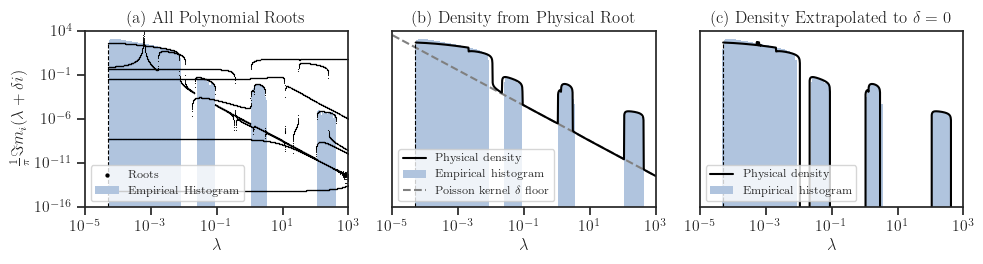


Changed af.delta_ladder to:
[1.e-06 2.e-06 3.e-06 4.e-06]



In [21]:
# Copy settigns so we can revert it later
orig_delta_ladder_size = af.inv_stieltjes_opt['delta_ladder_size']
orig_method = af.inv_stieltjes_opt['method']
orig_fit_degree = af.inv_stieltjes_opt['fit_degree']
set_delta_ladder(delta_ladder_size=1, method='direct')

x_min = 1e-5
x_max = 1e3

x_cand = numpy.geomspace(5e-5, x_max, 5000)
x_rho = numpy.geomspace(x_min, x_max, 500)
bins = numpy.geomspace(x_min, x_max, 200)

xlim = [x_min, x_max]
ylim = [1e-16, 1e4]

end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]
idx = end_idx
alpha = sizes[idx] / sizes[start_idx]
t_i = numpy.log(alpha)

newton_opt = dict(
    dt_max=0.001,
    dt_min=1e-10,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
    pair_enable=True,
    pair_gap_factor=10.0,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho_all, _ = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=False, latex=latex)
rho = rho_all[-1, :]

# Set to interpolate rho 
set_delta_ladder(delta_ladder_size=4, method='chebfit', fit_degree=2)

# Using extrapolation
rho_all2, _ = af.decompress(
    fd_sizes, x=x, kind='free', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=False, latex=latex)
rho2 = rho_all2[-1, :]


coeffs_i = decompress_coeffs(af.coeffs, t_i)

plot_candidate_comparison(x_cand, coeffs_i, x, rho, bins, eigs[idx], xlim, ylim, '-final', cut=5e-5,
                          rho2=rho2)

# Revert back to the original setting 
af.inv_stieltjes_opt['delta_ladder_size'] = orig_delta_ladder_size
af.inv_stieltjes_opt['method'] = orig_method
af.inv_stieltjes_opt['fit_degree'] = orig_fit_degree
set_delta_ladder(orig_delta_ladder_size, orig_method)